In [10]:
# [General Setup] 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
from tqdm.auto import tqdm
import warnings
from sklearn.model_selection import train_test_split

# Deep Learning & Torch
import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn, optim
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")

# Configurare Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Rulăm pe dispozitivul: {DEVICE}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


Rulăm pe dispozitivul: cpu


In [11]:
# [Configurare]

BASE_DIR = Path("C:\\Users\\bianc\\OneDrive\\Desktop\\an3_ISA\\SBC\\Proiect\\archive 2")
IMAGE_PATH = BASE_DIR / "images"
MASK_PATH = BASE_DIR / "masks"

color2id = {
    (0, 0, 0): 0,         # Background / Cer
    (184, 61, 245): 5,    # Vegetație / Copaci
    (255, 53, 94): 1,     # Road Sign (Semne)
    (255, 204, 51): 2,    # Car (Mașini - Clasa Critică pentru ADAS)
    (221, 255, 51): 3,    # Marking (Marcaje)
    (61, 61, 245): 4      # Road Surface (Asfalt - Critic pentru Lane Assist)
}

id2color = {v: k for k, v in color2id.items()}

print("| ID | Nume | RGB |")
print("|---:|:---|:---|")

for k, v in sorted(color2id.items(), key=lambda item: item[1]):
    print(f"| {v} | Clasa {v} | {k} |")


| ID | Nume | RGB |
|---:|:---|:---|
| 0 | Clasa 0 | (0, 0, 0) |
| 1 | Clasa 1 | (255, 53, 94) |
| 2 | Clasa 2 | (255, 204, 51) |
| 3 | Clasa 3 | (221, 255, 51) |
| 4 | Clasa 4 | (61, 61, 245) |
| 5 | Clasa 5 | (184, 61, 245) |


Se execută verificarea calității datelor...
Validare completă. Imagini valide: 31 din 31
Train: 21 | Val: 5 | Test: 5
Se calculează statisticile pe întregul set de date (poate dura puțin)...


Analiză Măști: 100%|██████████| 31/31 [00:03<00:00,  7.99it/s]


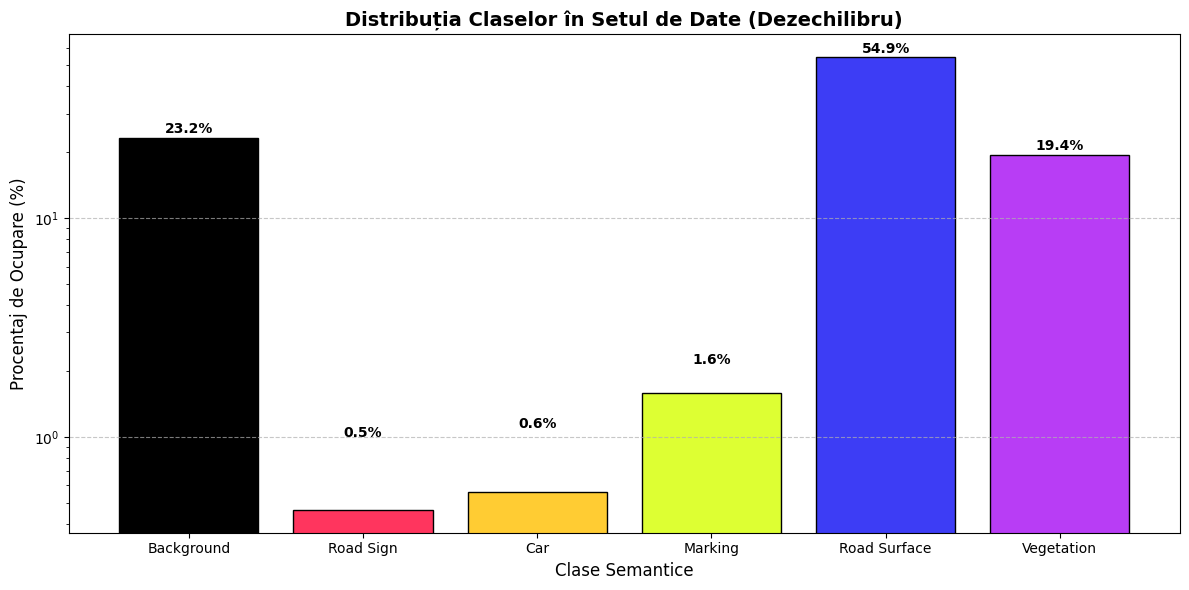

In [12]:
# [Validarea Datelor] 
def validate_dataset_integrity(image_paths, mask_paths):

    print("Se execută verificarea calității datelor...")
    valid_images = []
    valid_masks = []
    
    for img_p, mask_p in zip(image_paths, mask_paths):
        if not os.path.exists(img_p) or not os.path.exists(mask_p):
            continue
            
        try:
            # Încercăm o citire rapidă
            img_head = cv2.imread(str(img_p), cv2.IMREAD_UNCHANGED)
            if img_head is None: raise ValueError("Corrupt Image")
            valid_images.append(img_p)
            valid_masks.append(mask_p)
        except Exception:
            continue
            
    print(f"Validare completă. Imagini valide: {len(valid_images)} din {len(image_paths)}")
    return valid_images, valid_masks

# Colectare fișiere
all_images = sorted(list(IMAGE_PATH.glob("*.png")))
all_masks = sorted(list(MASK_PATH.glob("*.png")))

# Executare validare
val_imgs, val_msks = validate_dataset_integrity(all_images, all_masks)

# Creare DataFrame și Split
data = pd.DataFrame({'Image': val_imgs, 'Mask': val_msks})
data_train, data_rest = train_test_split(data, test_size=0.3, random_state=SEED)
data_val, data_test = train_test_split(data_rest, test_size=0.5, random_state=SEED)

print(f"Train: {len(data_train)} | Val: {len(data_val)} | Test: {len(data_test)}")

import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm.auto import tqdm

# Histograma pentru distributia claselor

def plot_class_distribution(mask_paths, color2id, id2color):

    print("Se calculează statisticile pe întregul set de date (poate dura puțin)...")
    
    class_pixel_counts = {id_val: 0 for id_val in color2id.values()}
    
    class_names = {
        0: "Background",
        1: "Road Sign",
        2: "Car",
        3: "Marking",
        4: "Road Surface",
        5: "Vegetation"
    }

    for mask_p in tqdm(mask_paths, desc="Analiză Măști"):
        # Citim masca
        mask = cv2.imread(str(mask_p))
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        mask_ids = np.zeros((mask.shape[0], mask.shape[1]), dtype=np.uint8)
        for color, class_id in color2id.items():
            matches = np.all(mask == np.array(color), axis=-1)
            mask_ids[matches] = class_id
       
        unique, counts = np.unique(mask_ids, return_counts=True)
        for u, c in zip(unique, counts):
            if u in class_pixel_counts:
                class_pixel_counts[u] += c

    labels = [class_names[i] for i in range(6)]
    values = [class_pixel_counts[i] for i in range(6)]
    
    total_pixels = sum(values)
    percentages = [(v / total_pixels) * 100 for v in values]
    
    bar_colors = [np.array(id2color[i])/255.0 for i in range(6)]

    plt.figure(figsize=(12, 6))
    bars = plt.bar(labels, percentages, color=bar_colors, edgecolor='black')

    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.title('Distribuția Claselor în Setul de Date (Dezechilibru)', fontsize=14, fontweight='bold')
    plt.xlabel('Clase Semantice', fontsize=12)
    plt.ylabel('Procentaj de Ocupare (%)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.yscale('log') 
    
    plt.tight_layout()
    plt.show()

plot_class_distribution(all_masks, color2id, id2color)



In [13]:
# [Preprocessing] 

# Filtru median
def apply_sensor_denoising(image):
    return cv2.medianBlur(image, 3)

# Transformare masca RGB in ID uri
def mapping_color(img_pil, color2id):
    image = np.array(img_pil)
    output_matrix = np.zeros((image.shape[0], image.shape[1]), dtype=np.int64)
    for color, class_id in color2id.items():
        matches = np.all(image == np.array(color), axis=-1)
        output_matrix[matches] = class_id
    return output_matrix

def fast_id2color(mask, id2color):
    mask_np = np.array(mask)
    h, w = mask_np.shape
    img_color = np.zeros((h, w, 3), dtype=np.uint8)
    
    for id_val, color in id2color.items():
        img_color[mask_np == id_val] = color
        
    return img_color

In [14]:
# [Augmentations]

class ADASDataset(Dataset):
    def __init__(self, data, color2id, transform=None, mode='train'):
        self.data = data
        self.color2id = color2id
        self.transform = transform
        self.mode = mode 
        
    def __getitem__(self, idx):
        img_path = str(self.data.iloc[idx, 0])
        mask_path = str(self.data.iloc[idx, 1])
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.mode == 'test':
            image = apply_sensor_denoising(image)

        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = mapping_color(mask, self.color2id)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask.long()

    def __len__(self):
        return len(self.data)

def calculate_dataset_statistics(image_paths):

    print("Se calculează statisticile setului de date (Mean & Std)...")
    
    psum    = torch.tensor([0.0, 0.0, 0.0])
    psum_sq = torch.tensor([0.0, 0.0, 0.0])
    count   = 0
    for img_path in tqdm(image_paths, desc="Calcul Statistici"):

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (640, 640))
        
        img = img.astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img)
        img_tensor = img_tensor.view(-1, 3) 
        
        psum    += img_tensor.sum(dim=0)
        psum_sq += (img_tensor ** 2).sum(dim=0)
        count   += img_tensor.shape[0] 

    # Formulele matematice
    total_mean = psum / count
    total_std  = torch.sqrt((psum_sq / count) - (total_mean ** 2))

    return total_mean, total_std

my_mean, my_std = calculate_dataset_statistics(val_imgs)

print("\n" + "="*40)
print(f"MEAN: {my_mean.numpy()}")
print(f"STD:  {my_std.numpy()}")
print("="*40)

my_mean = (0.519, 0.517, 0.487)
my_std  = (0.209, 0.202, 0.246)

train_transform = A.Compose([
    A.Resize(640, 640),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=my_mean, std=my_std), 
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=my_mean, std=my_std),
    ToTensorV2()
])

# Creare DataLoaders
train_ds = ADASDataset(data_train, color2id, transform=train_transform, mode='train')
val_ds = ADASDataset(data_val, color2id, transform=val_transform, mode='val')
test_ds = ADASDataset(data_test, color2id, transform=val_transform, mode='test')

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)



Se calculează statisticile setului de date (Mean & Std)...


Calcul Statistici: 100%|██████████| 31/31 [00:00<00:00, 45.44it/s]


MEAN: [0.51917267 0.5168241  0.48700708]
STD:  [0.20931011 0.20206292 0.24620269]


In [22]:
# [Reguli] 

class TrafficScenario:
    def __init__(self, car_density, road_visibility, has_sign):
        self.car_density = car_density         
        self.road_visibility = road_visibility 
        self.has_sign = has_sign               

class AdasDecisionSystem:
    def __init__(self):
        self.state = "UNKNOWN"
        self.action = "MONITOR"
        self.message = "Inițializare..."

    def evaluate(self, scenario: TrafficScenario):
        self.message = ""
        
        # 1. Verificare Bandă (Lane Assist) - Dacă nu vedem asfalt
        if scenario.road_visibility < 0.15:
            self.state = "CRITICAL"
            self.action = "LANE ASSIST WARNING"
            self.message = "PĂRĂSIRE BANDĂ! Drum nedetectat."

        # 2. Analiză Pericol Coliziune (Prea mult galben = obstacol aproape)
        elif scenario.car_density > 0.15:
            self.state = "DANGER"
            self.action = "EMERGENCY BRAKE"
            self.message = "FRÂNARE! Obstacol major în față."

        # 3. Avertismente Trafic (Galben mediu = mașini în față)
        elif 0.05 < scenario.car_density <= 0.15:
            self.state = "WARNING"
            self.action = "PREPARE BRAKE"
            self.message = "Atenție: Vehicule detectate. Păstrați distanța."
        
        # 4. Condiții Sigure
        else:
            self.state = "SAFE"
            self.action = "CRUISE CONTROL"
            self.message = "Condiții sigure de deplasare."

        # Adăugare info despre semne
        if scenario.has_sign:
            self.message += " | SEMN DETECTAT!"

def extract_facts_from_mask(mask_tensor):
    mask_np = mask_tensor.cpu().numpy()
    
    vehicle_pixels = np.sum(mask_np == 2) # ID 2 = Car
    road_pixels = np.sum(mask_np == 4)    # ID 4 = Road
    sign_pixels = np.sum(mask_np == 1)    # ID 1 = Sign
    
    car_density = vehicle_pixels / mask_np.size
    road_visibility = road_pixels / mask_np.size
    has_sign = sign_pixels > 50 
    
    return TrafficScenario(car_density, road_visibility, has_sign)

In [8]:

# 1. Importăm funcția de sumar (nou)
from torchinfo import summary

# 2. Definim Modelul: U-Net cu encoder ResNet34

model = smp.Unet(
    encoder_name="resnet34", 
    encoder_weights=None, 
    classes=6
).to(DEVICE)

print("Se generează sumarul modelului...")
summary(model=model, 
        input_size=(1, 3, 640, 640), 
        col_width=17, 
        col_names=['input_size', 'output_size', 'num_params', 'trainable'], 
        row_settings=['var_names'],
        verbose=1) 


loss_fn = smp.losses.DiceLoss(mode="multiclass", classes=6, ignore_index=-1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

Se generează sumarul modelului...
Layer (type (var_name))                            Input Shape       Output Shape      Param #           Trainable
Unet (Unet)                                        [1, 3, 640, 640]  [1, 6, 640, 640]  --                True
├─ResNetEncoder (encoder)                          [1, 3, 640, 640]  [1, 3, 640, 640]  --                True
│    └─Conv2d (conv1)                              [1, 3, 640, 640]  [1, 64, 320, 320] 9,408             True
│    └─BatchNorm2d (bn1)                           [1, 64, 320, 320] [1, 64, 320, 320] 128               True
│    └─ReLU (relu)                                 [1, 64, 320, 320] [1, 64, 320, 320] --                --
│    └─MaxPool2d (maxpool)                         [1, 64, 320, 320] [1, 64, 160, 160] --                --
│    └─Sequential (layer1)                         [1, 64, 160, 160] [1, 64, 160, 160] --                True
│    │    └─BasicBlock (0)                         [1, 64, 160, 160] [1, 64, 160, 160

In [16]:
# Funcție ajutătoare pentru calcul IoU 
def get_iou_score(model, loader, device="cuda"):
    model.eval()
    iou_score = 0
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device).float(), y.to(device).long()
            
            preds = model(x)
            pred_mask = torch.softmax(preds, dim=1).argmax(dim=1)
            
            tp, fp, fn, tn = smp.metrics.get_stats(
                pred_mask.long(), 
                y, 
                mode='multiclass', 
                num_classes=6, 
                ignore_index=-1
            )
            
            iou_score += smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
            
    return iou_score / len(loader)

def train_one_epoch(model, loader, optimizer, loss_fn, device="cuda"):
    model.train()
    epoch_loss = 0
    
    for x, y in tqdm(loader, desc="Training"):
        x, y = x.to(device).float(), y.to(device).long()
        
        optimizer.zero_grad()
        preds = model(x)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    return epoch_loss / len(loader)

def validate(model, loader, loss_fn, device="cuda"):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device).float(), y.to(device).long()
            preds = model(x)
            val_loss += loss_fn(preds, y).item()
    return val_loss / len(loader)

In [19]:
#[Antrenare]
EPOCHS = 35 
history = {'train_loss': [], 'val_loss': [], 'train_iou': [], 'val_iou': []}

best_valid_loss = float('inf')

print(f"Începem antrenarea pentru {EPOCHS} epoci...")

for epoch in range(EPOCHS):
    # 1. Antrenare & Validare
    t_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    v_loss = validate(model, val_loader, loss_fn, DEVICE)
    t_iou = get_iou_score(model, train_loader, DEVICE)
    v_iou = get_iou_score(model, val_loader, DEVICE)
    
    # 2. Scheduler
    scheduler.step(v_loss)
    
    # 3. Salvare Istoric
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_iou'].append(t_iou)
    history['val_iou'].append(v_iou)
    
    if v_loss < best_valid_loss:
        best_valid_loss = v_loss
        torch.save(model.state_dict(), "adas_model_final.pth")
        save_msg = "💾 Model Salvat (Best Score!)"
    else:
        save_msg = ""
        
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {t_loss:.4f}/{v_loss:.4f} | IoU: {t_iou:.4f}/{v_iou:.4f} | {save_msg}")

print("Antrenare completă. Cel mai bun model a fost salvat în 'adas_model_final.pth'.")

Începem antrenarea pentru 35 epoci...


Training: 100%|██████████| 11/11 [00:34<00:00,  3.10s/it]


Epoch 1/35 | Loss: 0.1688/0.1499 | IoU: 0.9379/0.9599 | 💾 Model Salvat (Best Score!)


Training: 100%|██████████| 11/11 [00:32<00:00,  2.98s/it]


Epoch 2/35 | Loss: 0.1518/0.1396 | IoU: 0.9556/0.9540 | 💾 Model Salvat (Best Score!)


...

Epoch 33/35 | Loss: 0.0727/0.1381 | IoU: 0.9480/0.9670 | 


Training: 100%|██████████| 11/11 [00:32<00:00,  2.93s/it]


Epoch 34/35 | Loss: 0.0815/0.1358 | IoU: 0.9703/0.9670 | 💾 Model Salvat (Best Score!)


Training: 100%|██████████| 11/11 [00:32<00:00,  2.96s/it]


Epoch 35/35 | Loss: 0.0773/0.1388 | IoU: 0.8859/0.9669 | 
Antrenare completă. Cel mai bun model a fost salvat în 'adas_model_final.pth'.


Model încărcat cu succes pentru generarea matricei.
Se calculează Matricea de Confuzie (așteaptă câteva secunde)...


Procesare Matrice: 100%|██████████| 5/5 [00:03<00:00,  1.59it/s]


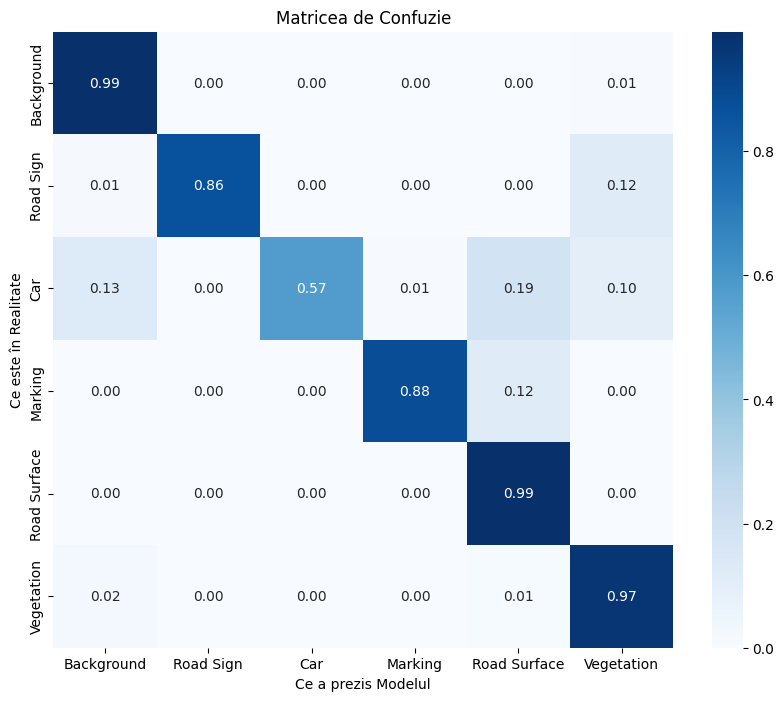

In [20]:
# [Matricea de Confuzi]
import seaborn as sns
from sklearn.metrics import confusion_matrix

def compute_and_plot_confusion_matrix(model, loader, device, classes):

    if os.path.exists("adas_model_final.pth"):
        model.load_state_dict(torch.load("adas_model_final.pth"))
        print("Model încărcat cu succes pentru generarea matricei.")
    else:
        print("ATENȚIE: Nu s-a găsit modelul antrenat! Matricea va fi greșită.")
    
    print("Se calculează Matricea de Confuzie (așteaptă câteva secunde)...")
    
    y_true_all = []
    y_pred_all = []
    
    model.eval()
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Procesare Matrice"):
            x = x.to(device).float()
            
            output = model(x)
            pred_mask = torch.softmax(output, dim=1).argmax(dim=1).cpu().numpy()
            true_mask = y.numpy()
            y_true_all.extend(true_mask.flatten()[::100])
            y_pred_all.extend(pred_mask.flatten()[::100])
            
    # Calculăm matricea
    cm = confusion_matrix(y_true_all, y_pred_all, labels=range(len(classes)))
    
    # Normalizare
    cm_sum = cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = cm.astype('float') / (cm_sum + 1e-10)
    
    # Plotare
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    
    plt.title('Matricea de Confuzie')
    plt.xlabel('Ce a prezis Modelul')
    plt.ylabel('Ce este în Realitate')
    plt.show()

class_names = ["Background", "Road Sign", "Car", "Marking", "Road Surface", "Vegetation"]

# Apelăm funcția
compute_and_plot_confusion_matrix(model, val_loader, DEVICE, class_names)

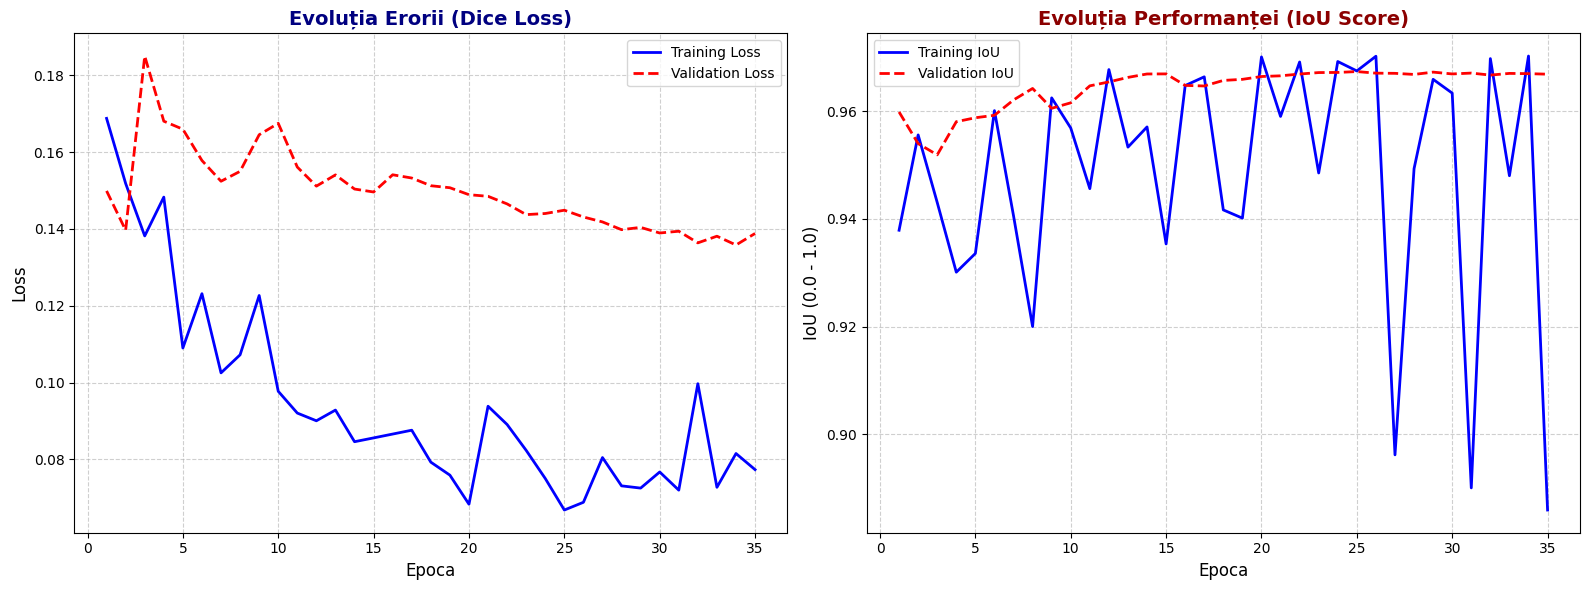

In [ ]:


def plot_training_results(results: dict):
   
    # Extragem datele din dicționarul history
    training_loss = results['train_loss']
    valid_loss = results['val_loss']
    training_iou = results['train_iou']
    valid_iou = results['val_iou']
    
    # Definim axa X (numărul de epoci)
    epochs = range(1, len(training_loss) + 1)
    
    # Creăm cadrul grafic (2 grafice unul lângă altul)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))
    
    # --- GRAFIC 1: EVOLUȚIA ERORII (LOSS) ---
    axes[0].plot(epochs, training_loss, 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, valid_loss, 'r--', label='Validation Loss', linewidth=2)
    
    axes[0].set_title("Evoluția Erorii (Dice Loss)", fontsize=14, fontweight="bold", color="navy")
    axes[0].set_xlabel("Epoca", fontsize=12)
    axes[0].set_ylabel("Loss", fontsize=12)
    axes[0].legend(fontsize=10) # Afișează legenda (care linie e care)
    axes[0].grid(True, linestyle='--', alpha=0.6) # Adaugă un grilaj fin pentru citire ușoară
    
    # --- GRAFIC 2: EVOLUȚIA PERFORMANȚEI (IoU) ---
    axes[1].plot(epochs, training_iou, 'b-', label='Training IoU', linewidth=2)
    axes[1].plot(epochs, valid_iou, 'r--', label='Validation IoU', linewidth=2)
    
    axes[1].set_title("Evoluția Performanței (IoU Score)", fontsize=14, fontweight="bold", color="darkred")
    axes[1].set_xlabel("Epoca", fontsize=12)
    axes[1].set_ylabel("IoU (0.0 - 1.0)", fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Apelăm funcția cu istoricul salvat în bucla de antrenare
# Asigură-te că ai rulat celula de antrenare înainte!
if 'history' in locals():
    plot_training_results(history)
else:
    print("Nu există istoric de antrenare. Rulează întâi antrenamentul!")

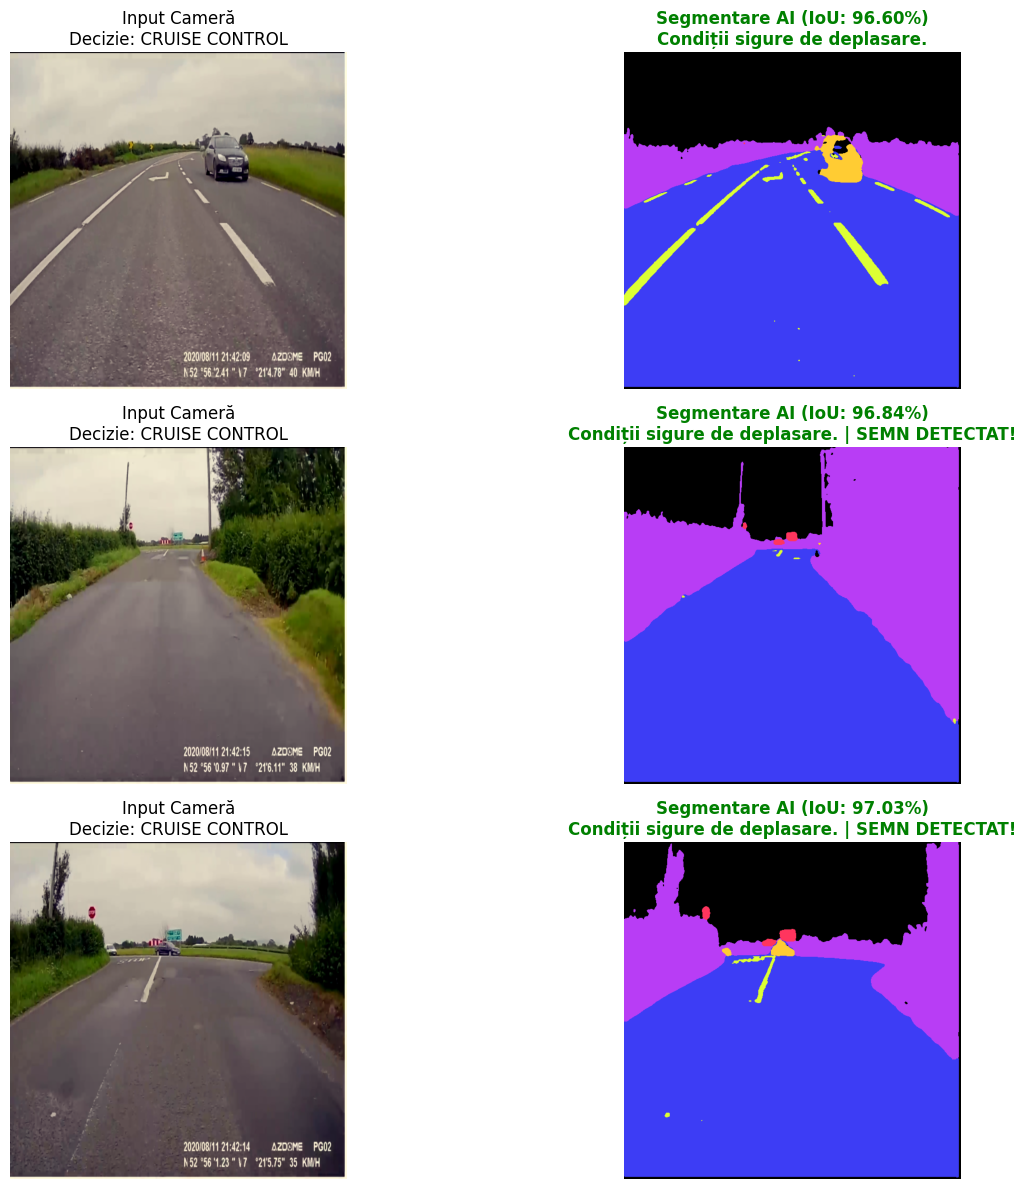

In [23]:
# [Demo Final] Vizualizare + Scorul IoU per imagine

adas_logic = AdasDecisionSystem()
# Pregătim datele
iterator = iter(test_loader)
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for i in range(3):
    try:
        img, mask_gt = next(iterator) 
    except StopIteration:
        break
        
    img_dev = img.to(DEVICE).float()
    
    # 1. Obținem Predicția AI
    with torch.no_grad():
        output = model(img_dev)
        pred_mask = torch.softmax(output, dim=1).argmax(dim=1).squeeze(0)
    
    # --- ZONA NOUĂ: CALCUL IoU (Conform Lab 6) ---
    # Comparăm ce a scos modelul (pred_mask) cu ce trebuia să iasă (mask_gt)
    tp, fp, fn, tn = smp.metrics.get_stats(
        pred_mask.unsqueeze(0).long(), # Adăugăm dimensiunea de batch
        mask_gt.to(DEVICE).long(), 
        mode='multiclass', 
        num_classes=6
    )
    
    # Calculăm scorul și îl transformăm în procent
    iou_val = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro").item()
    procent_iou = iou_val * 100
    # ---------------------------------------------

    # 2. Logica Sistemului Expert (Lab 7)
    scenario = extract_facts_from_mask(pred_mask)
    adas_logic.evaluate(scenario)
    
    # --- Vizualizare ---
    
    # Imagine Originală
    img_np = img.squeeze(0).permute(1, 2, 0).numpy()
    img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_np = np.clip(img_np, 0, 1)
    
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Input Cameră\nDecizie: {adas_logic.action}")
    axes[i, 0].axis('off')
    
    # Masca Segmentată + Afișare PROCENT IoU
    mask_vis = fast_id2color(pred_mask.cpu().numpy(), id2color)
    axes[i, 1].imshow(mask_vis)
    
    color_alert = "green" if adas_logic.state == "SAFE" else "red" if adas_logic.state in ["DANGER", "CRITICAL"] else "orange"
    
    # Aici afișăm procentul IoU în titlu!
    axes[i, 1].set_title(f"Segmentare AI (IoU: {procent_iou:.2f}%)\n{adas_logic.message}", 
                        color=color_alert, fontweight="bold")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

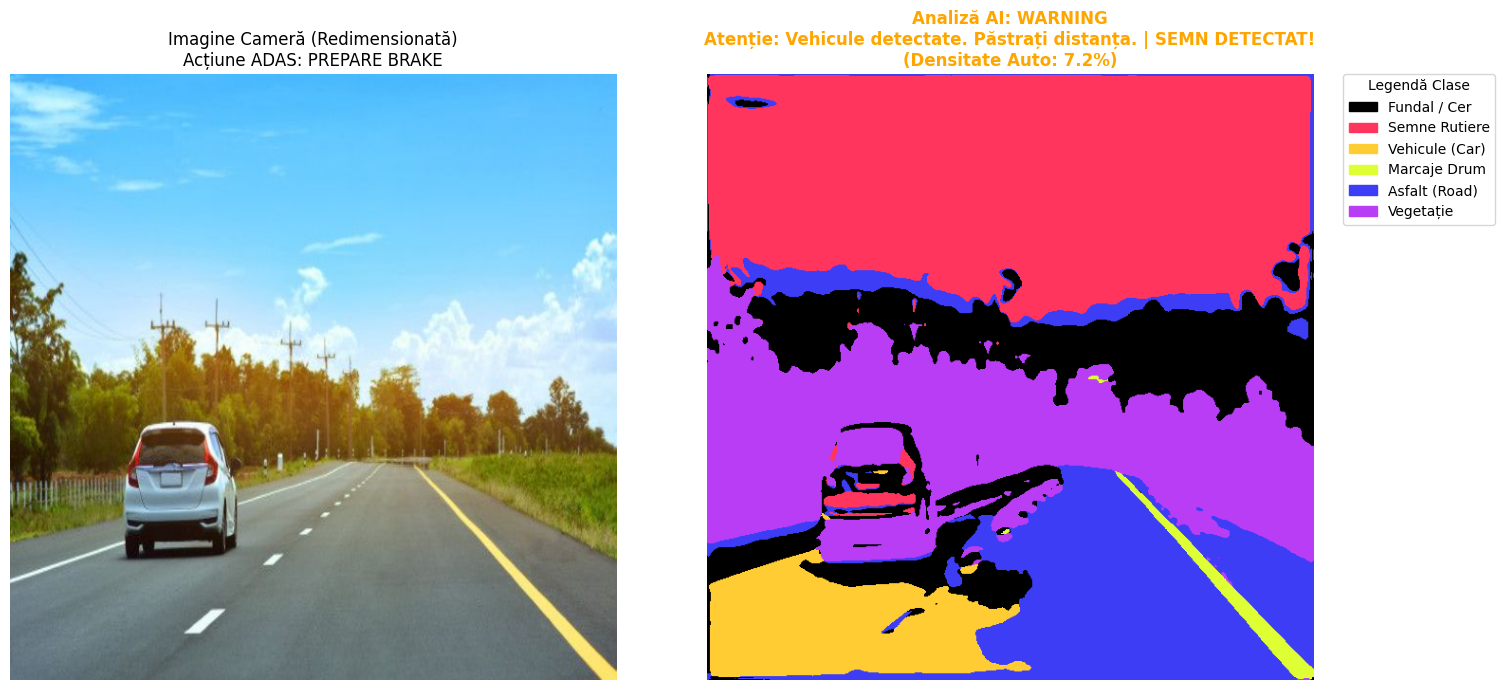

In [ ]:
# [Demo Real-World] Testare Simplă pe Imagine Nouă
import matplotlib.patches as mpatches

def predict_on_new_image(model, image_path, transform, device):
    if not os.path.exists(image_path):
        print(f"Eroare: Imaginea nu există la calea: {image_path}")
        return None, None, None, None
        
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (640, 640))
    original_image = image.copy()
    
    # Preprocesare
    augmented = transform(image=image)
    input_tensor = augmented['image'].unsqueeze(0).to(device)
    
    # Predicție Model
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.softmax(output, dim=1).argmax(dim=1).squeeze(0)
    
    # Analiză Sistem Expert
    scenario = extract_facts_from_mask(pred_mask)
    adas_system = AdasDecisionSystem()
    adas_system.evaluate(scenario)
    
    return original_image, pred_mask.cpu().numpy(), adas_system, scenario


NEW_IMAGE_PATH = r"C:\Users\bianc\OneDrive\Desktop\an3_ISA\SBC\Proiect\archive 2\road2.jpg" 

res_img, res_mask, system_decision, stats = predict_on_new_image(
    model, 
    NEW_IMAGE_PATH, 
    val_transform, 
    DEVICE
)

if res_img is not None:
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    
    # 1. Imaginea Originală
    ax[0].imshow(res_img)
    ax[0].set_title(f"Imagine Cameră (Redimensionată)\nAcțiune ADAS: {system_decision.action}")
    ax[0].axis('off')
    
    # 2. Masca Segmentată Colorată
    colored_mask = fast_id2color(res_mask, id2color)
    ax[1].imshow(colored_mask)
    
    # Configurare titlu alertă
    color_text = "green" if system_decision.state == "SAFE" else "red" if system_decision.state in ["DANGER", "CRITICAL"] else "orange"
    
    ax[1].set_title(f"Analiză AI: {system_decision.state}\n{system_decision.message}\n(Densitate Auto: {stats.car_density:.1%})", 
                    color=color_text, fontweight="bold", fontsize=12)
    ax[1].axis('off')

    # Legendă
    legend_dict = {
        "Fundal / Cer": (0, 0, 0),
        "Semne Rutiere": (255, 53, 94),
        "Vehicule (Car)": (255, 204, 51),
        "Marcaje Drum": (221, 255, 51),
        "Asfalt (Road)": (61, 61, 245),
        "Vegetație": (184, 61, 245)
    }
    legend_patches = [mpatches.Patch(color=np.array(c)/255.0, label=n) for n, c in legend_dict.items()]
    ax[1].legend(handles=legend_patches, title="Legendă Clase", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.tight_layout()
    plt.show()